Logistic regression model for predicting abnormal CMP results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    f1_score,
    confusion_matrix,
    classification_report
)

1.) Load dataset and basic cleaning

In [2]:
df = pd.read_csv("data/processed/final_model_df.csv", parse_dates=["charttime"])

# Drop duplicates and empty cells as a safety condition, assert subject_id and target_abnormal are integers
df = df.dropna(subset=["subject_id", "target_abnormal"]).drop_duplicates().copy()
df["subject_id"] = df["subject_id"].astype(int)
df["target_abnormal"] = df["target_abnormal"].astype(int)

print("Dataset shape:", df.shape)
print("Target distribution:")
print(df["target_abnormal"].value_counts(normalize=True))

Dataset shape: (2914207, 55)
Target distribution:
target_abnormal
1    0.889656
0    0.110344
Name: proportion, dtype: float64


2.) Feature selection

In [3]:
# Should not be used for training
exclude_cols = {
    "subject_id",
    "hadm_id",
    "target_abnormal",
    "charttime",
    "prev_cmp_time",
    "chartdate",
    "admittime",
}

# Selected numeric feature groups
numeric_features = [
    "age",
    "length_of_stay_hours",
    "hours_since_last_cmp",
    "prior_abnormal_cmp_count",
    "abnormal_last_5_events",
    "bmi",
    "sbp",
    "dbp"
]

# Automatically detected prior lab value, lab value change, and diagnosis feature groups
prior_cols = [
    c for c in df.columns
    if c.startswith("prev_") and c not in exclude_cols and "time" not in c.lower() and "date" not in c.lower()
]

delta_cols = [
    c for c in df.columns
    if c.startswith("delta_") and c not in exclude_cols and "time" not in c.lower() and "date" not in c.lower()
]

diag_cols = [
    c for c in df.columns
    if c.startswith("dx_")
]

numeric_features = numeric_features + prior_cols + delta_cols + diag_cols

numeric_features = [c for c in numeric_features if c in df.columns and c not in exclude_cols]

# Selected categorical features
categorical_features = [
    "sex",
    "admission_type",
]

# All features
feature_cols = numeric_features + categorical_features

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))
print("Number of diagnosis features:", len(diag_cols))

Number of numeric features: 47
Number of categorical features: 2
Number of diagnosis features: 11


3.) Split dataset by patient into training, testing, and validation datasets

In [4]:
train_ratio = 0.70
test_ratio = 0.15
val_ratio = 0.15

# Create smaller dataframe using feature columns, patient ID, and coded abnormal flag
model_df = df[["subject_id"] + feature_cols + ["target_abnormal"]].copy()

# Splits to training and temporary groups by patient ID
gss1 = GroupShuffleSplit(n_splits=1, test_size=test_ratio + val_ratio, random_state=0)
train_idx, temp_idx = next(gss1.split(model_df, groups=model_df["subject_id"]))

train_df = model_df.iloc[train_idx].copy()
temp_df = model_df.iloc[temp_idx].copy()

# Splits temporary into test and validation by patient ID
gss2 = GroupShuffleSplit(n_splits=1, test_size=test_ratio / (test_ratio + val_ratio), random_state=0)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["subject_id"]))

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

total_rows = train_df.shape[0] + val_df.shape[0] + test_df.shape[0]

print("Train shape (" + f"{train_df.shape[0] / total_rows:.2%}" + "):", train_df.shape)
print("Validation shape (" + f"{val_df.shape[0] / total_rows:.2%}" + "):", val_df.shape)
print("Test shape (" + f"{test_df.shape[0] / total_rows:.2%}" + "):", test_df.shape)

Train shape (69.77%): (2033350, 51)
Validation shape (15.04%): (438153, 51)
Test shape (15.19%): (442704, 51)


In [5]:
target_col = "target_abnormal"

# Separate classes
train_majority = train_df[train_df[target_col] == 1]
train_minority = train_df[train_df[target_col] == 0]

# Downsample class 1 to match class 0
train_majority_downsampled = train_majority.sample(
    n=len(train_minority),
    random_state=0
)

# Combine back
train_df_balanced = pd.concat([train_majority_downsampled, train_minority])

# Shuffle
train_df_balanced = train_df_balanced.sample(frac=1, random_state=0).reset_index(drop=True)

In [6]:
# Training set
X_train = train_df_balanced[feature_cols]
y_train = train_df_balanced[target_col]

# Validation set
X_val = val_df[feature_cols]
y_val = val_df["target_abnormal"]

# Testing set
X_test = test_df[feature_cols]
y_test = test_df["target_abnormal"]

4.) Build pipelines and train model

In [7]:
# Fill in missing values with median, standardize values across numeric features to prevent size dominance due to scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Fill in missing categories with most frequent, convert categories to one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

logreg_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight={0: 3, 1: 1},
        penalty="l2",
        solver="liblinear",
        C=1,
        random_state=0,
    ))
])

logreg_model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


5.) Tune classification threshold with validation set

In [8]:
def compute_metrics_at_threshold(y_true, y_prob, threshold):
    """Converts model output probability to class based on threshold

    Args:
        y_true (int): Label from dataset
        y_prob (float): Predicted probability
        threshold (float): Cutoff point for probabilities to class predictions

    Returns:
        Computed metrics at that threshold
    """
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)
    f1 = f1_score(y_true, y_pred)

    return {
        "threshold": threshold,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "ppv": ppv,
        "npv": npv,
        "f1": f1
    }

In [9]:
# Compute AUROC for validation set
val_probs = logreg_model.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, val_probs)

# Evaluate all thresholds in 0.05 increments from 0.10 to 0.90
thresholds = np.arange(0.10, 0.91, 0.05)
val_results = [compute_metrics_at_threshold(y_val, val_probs, t) for t in thresholds]
val_results_df = pd.DataFrame(val_results)

# Target threshold values based on sensitivity as most improtant metric
target_sensitivity = 0.8
eligible = val_results_df[val_results_df["sensitivity"] >= target_sensitivity].copy()

# Rank thresholds that exceed the target sensitivity by sensitivity and f1 score
chosen_row = eligible.sort_values(by=["specificity", "f1"], ascending=False).iloc[0]
chosen_threshold = float(chosen_row["threshold"])

print(f"Validation AUROC: {val_auc:.4f}")
print("Chosen threshold:", chosen_threshold)
display(val_results_df)

Validation AUROC: 0.7599
Chosen threshold: 0.15000000000000002


,threshold,sensitivity,specificity,ppv,npv,f1
0,0.10,0.929475,0.268481,0.911603,0.319287,0.920452
1,0.15,0.863167,0.431226,0.924909,0.279692,0.892972
2,0.20,0.790371,0.569232,0.937074,0.250694,0.857493
3,0.25,0.705581,0.688284,0.948377,0.223625,0.809158
4,0.30,0.609808,0.787570,0.958846,0.199160,0.745495
5,0.35,0.511361,0.856459,0.966571,0.177602,0.668863
6,0.40,0.416868,0.903335,0.972223,0.160275,0.583531
7,0.45,0.331972,0.931236,0.975114,0.146580,0.495316
8,0.50,0.260965,0.950690,0.977249,0.136812,0.411929
9,0.55,0.201976,0.964068,0.978551,0.129562,0.334841


6.) Evaluate on test set and classification report

In [10]:
test_probs = logreg_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_probs)

test_metrics = compute_metrics_at_threshold(y_test, test_probs, chosen_threshold)
test_preds = (test_probs >= chosen_threshold).astype(int)

print(f"Test AUROC: {test_auc:.4f}")
print("Test metrics:")
for k, v in test_metrics.items():
    if k != "threshold":
        print(f"{k}: {v:.4f}")

print("\nClassification report:")
print(classification_report(y_test, test_preds, digits=4))

Test AUROC: 0.7584
Test metrics:
sensitivity: 0.8644
specificity: 0.4301
ppv: 0.9244
npv: 0.2823
f1: 0.8934

Classification report:
              precision    recall  f1-score   support

           0     0.2823    0.4301    0.3409     48847
           1     0.9244    0.8644    0.8934    393857

    accuracy                         0.8164    442704
   macro avg     0.6033    0.6472    0.6171    442704
weighted avg     0.8536    0.8164    0.8324    442704



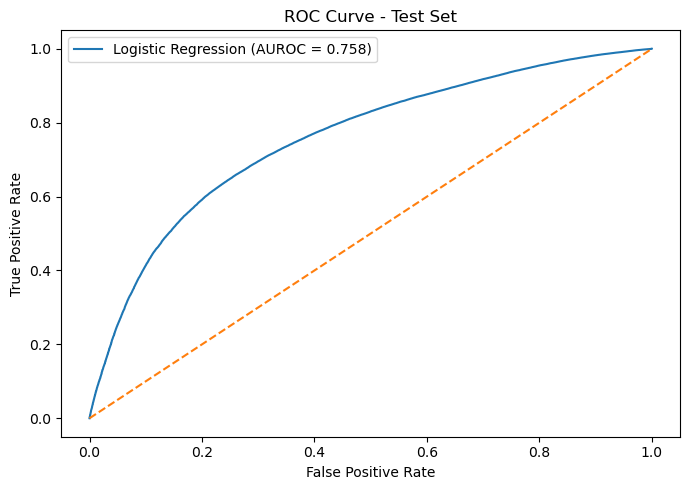

In [11]:
# Display ROC curve
fpr, tpr, _ = roc_curve(y_test, test_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUROC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.tight_layout()
plt.show()

7.) Coefficient analysis

In [12]:
clf = logreg_model.named_steps["clf"]
feature_names = logreg_model.named_steps["preprocess"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": clf.coef_[0]
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])

print("Top positive predictors:")
display(coef_df.sort_values("coefficient", ascending=False).head(15))

print("Top negative predictors:")
display(coef_df.sort_values("coefficient", ascending=True).head(15))

Top positive predictors:


,feature,coefficient,abs_coefficient,odds_ratio
4,num__abnormal_last_5_events,0.542387,0.542387,1.720108
21,num__prev_bun,0.340689,0.340689,1.405916
17,num__prev_glucose,0.236761,0.236761,1.267138
55,cat__admission_type_OBSERVATION ADMIT,0.190596,0.190596,1.209971
35,num__delta_bun,0.185025,0.185025,1.203249
54,cat__admission_type_EW EMER.,0.153970,0.153970,1.166456
46,num__dx_other,0.151692,0.151692,1.163801
0,num__age,0.144000,0.144000,1.154884
36,num__dx_icd10_e11,0.121173,0.121173,1.128820
10,num__prev_alp,0.120669,0.120669,1.128251


Top negative predictors:


,feature,coefficient,abs_coefficient,odds_ratio
49,cat__admission_type_AMBULATORY OBSERVATION,-0.490002,0.490002,0.612625
47,cat__sex_F,-0.395037,0.395037,0.673655
48,cat__sex_M,-0.370018,0.370018,0.690722
51,cat__admission_type_DIRECT OBSERVATION,-0.331985,0.331985,0.717498
52,cat__admission_type_ELECTIVE,-0.174848,0.174848,0.839585
14,num__prev_total_calcium,-0.162698,0.162698,0.849848
28,num__delta_total_calcium,-0.157453,0.157453,0.854317
56,cat__admission_type_SURGICAL SAME DAY ADMISSION,-0.137284,0.137284,0.871722
11,num__prev_ast,-0.089570,0.089570,0.914324
18,num__prev_potassium,-0.085017,0.085017,0.918497


In [13]:
val_results_df.to_csv("data/processed/validation_threshold_results.csv", index=False)
coef_df.to_csv("data/processed/logreg_coefficients.csv", index=False)

summary_df = pd.DataFrame([{
    "model": "logistic_regression",
    "threshold": chosen_threshold,
    "validation_auroc": val_auc,
    "test_auroc": test_auc,
    "test_sensitivity": test_metrics["sensitivity"],
    "test_specificity": test_metrics["specificity"],
    "test_ppv": test_metrics["ppv"],
    "test_npv": test_metrics["npv"],
    "test_f1": test_metrics["f1"]
}])

summary_df.to_csv("data/processed/logreg_model_summary.csv", index=False)
summary_df

,model,threshold,validation_auroc,test_auroc,test_sensitivity,test_specificity,test_ppv,test_npv,test_f1
0,logistic_regression,0.15,0.759876,0.758394,0.864352,0.430139,0.924414,0.282266,0.893374
